# GeoBrain Rock Physics Example

From Porosity to Elastic Properties using VRH, Soft Sand, and Gassmann models.

---

**Rock-physics modelling** transforms geological properties (porosity,
mineral composition, fluid saturation) into elastic parameters
(bulk/shear moduli, P- and S-wave velocities).

This notebook follows the standard workflow:

```
Mineral mixing (VRH) → Dry frame (Soft Sand) → Fluid substitution (Gassmann) → Vp, Vs
```

In [1]:
import sys
import os
sys.path.insert(0, '../..')

import torch
import matplotlib.pyplot as plt

from geobrain.geomodel import Simulator, CoSimConfig
from geobrain.data.transforms import sigmoid_transform
from geobrain.physics.rock import VRH, Gassmann, SoftSand, DensityModel, v_from_moduli
from geobrain.vis import plot_field

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.manual_seed(2025)
print(f"Using device: {device}")

Using device: cuda


In [2]:
import matplotlib
matplotlib.rcParams.update({
    'figure.dpi': 150,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
    'savefig.pad_inches': 0.1,
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'axes.titleweight': 'semibold',
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
    'legend.framealpha': 0.9,
    'figure.facecolor': 'white',
    'axes.facecolor': '#fafafa',
    'axes.edgecolor': '#cccccc',
    'axes.linewidth': 0.8,
    'grid.color': '#e0e0e0',
    'grid.linewidth': 0.5,
    'lines.linewidth': 1.5,
    'image.cmap': 'viridis',
})

FIGS_DIR = os.path.join('..', 'figs')
os.makedirs(FIGS_DIR, exist_ok=True)

## Input Parameters

| Category | Parameters |
|----------|-----------|
| **Minerals** | Quartz (K = 36.6 GPa, G = 44.0 GPa) and clay (K = 21.0 GPa, G = 9.0 GPa), with densities and volume fractions |
| **Fluids** | Water (K = 3.06 GPa) and gas (K = 0.10 GPa) with corresponding densities |
| **Rock frame** | Effective pressure 20 MPa, critical porosity 0.4, coordination number 7 |

In [3]:
# Grid dimensions
NX, NY, NZ = 64, 64, 128

# Property ranges
phi_range = (0.05, 0.4)
vsand_range = (0.2, 0.8)
target_corr = 0.7

# Mineral parameters (quartz and clay)
MINERAL_PARAMS = {
    "Kminc": torch.tensor([36.6, 21.0], device=device),    # Bulk moduli (GPa)
    "Gminc": torch.tensor([44.0, 9.0], device=device),     # Shear moduli (GPa)
    "Rhominc": torch.tensor([2.65, 2.5], device=device),   # Densities (g/cm³)
    "Volminc": torch.tensor([0.9, 0.1], device=device)     # Volume fractions
}

# Fluid parameters (water and gas)
FLUID_PARAMS = {
    "Kflc": torch.tensor([3.06, 0.10], device=device),     # Bulk moduli (GPa)
    "Rhoflc": torch.tensor([1.08, 0.72], device=device),   # Densities (g/cm³)
    "patchy": 0.0                                          # Fluid mixing (0=Reuss, 1=Voigt)
}

# Rock physics settings
EFFECTIVE_PRESSURE = 20      # MPa
CRITICAL_POROSITY = 0.4
COORDINATION_NUMBER = 7

## Generate Geological Model

Co-simulation (FFT-MA) produces spatially correlated porosity and sand
volume fields with a cross-correlation of 0.7.  A sigmoid transform maps
each field into its physical range.

In [4]:
# Correlation matrix for co-simulation
correlation_matrix = torch.tensor([
    [1.0, target_corr],
    [target_corr, 1.0]
])

config = CoSimConfig(
    shape=(NX, NY, NZ),
    n_variables=2,
    correlation_matrix=correlation_matrix,
    field_names=["phi", "vsand"],
    lh=20,
    lv=5,
    device=str(device),
    seed=2025
)

simulator = Simulator.create('fft_ma')
fields = simulator.simulate(config)

# Transform to physical ranges
stacked = torch.stack([fields["phi"].cpu(), fields["vsand"].cpu()])
transformed = sigmoid_transform(stacked, ranges=[phi_range, vsand_range])

phi = transformed[0].to(device)
vsand = transformed[1].to(device)

print(f"Porosity: range=[{phi.min():.3f}, {phi.max():.3f}]")
print(f"Sand Volume: range=[{vsand.min():.3f}, {vsand.max():.3f}]")

Porosity: range=[0.056, 0.395]
Sand Volume: range=[0.209, 0.790]


## Rock-Physics Forward Chain

The modelling proceeds in five steps:

1. **VRH averaging** (Voigt–Reuss–Hill): computes effective mineral moduli.
   Voigt = upper bound, Reuss = lower bound, Hill = arithmetic mean.
2. **Fluid mixing**: Reuss average (`patchy = 0`) for uniform saturation,
   Voigt average (`patchy = 1`) for patchy saturation.
3. **Soft Sand model**: Hertz–Mindlin contact theory → dry-frame moduli.
   Suitable for unconsolidated to weakly cemented sandstones.
4. **Gassmann fluid substitution**: combines dry-frame and fluid properties
   to yield saturated-rock moduli.
5. **Velocity computation**:

$$V_p = \sqrt{\frac{K_{\text{sat}} + \tfrac{4}{3}G_{\text{sat}}}{\rho}}, \qquad V_s = \sqrt{\frac{G_{\text{sat}}}{\rho}}$$

In [5]:
# Initialize rock physics models
vrh = VRH()
soft_sand = SoftSand()
gassmann = Gassmann()
density_model = DensityModel()

# -----------------------------------------------------------------------------
# Mineral Properties (VRH Averaging)
# -----------------------------------------------------------------------------

vol = MINERAL_PARAMS["Volminc"]
Kminc = MINERAL_PARAMS["Kminc"]
Gminc = MINERAL_PARAMS["Gminc"]

# VRH averaging for mineral moduli
_, _, K_m = vrh(vol, Kminc)  # Returns (Voigt, Reuss, Hill)
_, _, G_m = vrh(vol, Gminc)
rho_m = (MINERAL_PARAMS["Rhominc"] * vol).sum()

print(f"Mineral bulk modulus (K_m): {K_m:.2f} GPa")
print(f"Mineral shear modulus (G_m): {G_m:.2f} GPa")
print(f"Mineral density (rho_m): {rho_m:.2f} g/cm³")

# -----------------------------------------------------------------------------
# Fluid Properties
# -----------------------------------------------------------------------------

# Water saturation (100% water in this example)
Sw = torch.ones_like(phi, device=device)

k_w, k_hc = FLUID_PARAMS["Kflc"]
rho_w, rho_hc = FLUID_PARAMS["Rhoflc"]
patchy = FLUID_PARAMS["patchy"]

# Fluid mixing (Reuss average for patchy=0)
if patchy > 0:
    k_fl = Sw * k_w + (1 - Sw) * k_hc
else:
    k_fl = 1.0 / (Sw / k_w + (1 - Sw) / k_hc)

rho_fl = Sw * rho_w + (1 - Sw) * rho_hc

print(f"Fluid bulk modulus: {k_fl.mean():.2f} GPa")
print(f"Fluid density: {rho_fl.mean():.2f} g/cm³")

# -----------------------------------------------------------------------------
# Dry Frame Properties (Soft Sand Model)
# -----------------------------------------------------------------------------

press = torch.ones_like(phi, device=device) * EFFECTIVE_PRESSURE

k_dry, g_dry = soft_sand(
    K_m, G_m, phi,
    CRITICAL_POROSITY,
    COORDINATION_NUMBER,
    press
)

print(f"Dry bulk modulus: range=[{k_dry.min():.2f}, {k_dry.max():.2f}] GPa")
print(f"Dry shear modulus: range=[{g_dry.min():.2f}, {g_dry.max():.2f}] GPa")

# -----------------------------------------------------------------------------
# Saturated Properties (Gassmann)
# -----------------------------------------------------------------------------

k_sat, g_sat = gassmann(k_dry, g_dry, K_m, k_fl, phi)
rho = density_model(phi, rho_m, rho_fl)

print(f"Saturated bulk modulus: range=[{k_sat.min():.2f}, {k_sat.max():.2f}] GPa")
print(f"Saturated shear modulus: range=[{g_sat.min():.2f}, {g_sat.max():.2f}] GPa")
print(f"Bulk density: range=[{rho.min():.2f}, {rho.max():.2f}] g/cm³")

# -----------------------------------------------------------------------------
# Elastic Velocities
# -----------------------------------------------------------------------------

# Use v_from_moduli for robust velocity computation
vp, vs = v_from_moduli(k_sat, g_sat, rho)

print(f"Vp: range=[{vp.min():.2f}, {vp.max():.2f}] km/s")
print(f"Vs: range=[{vs.min():.2f}, {vs.max():.2f}] km/s")
print(f"Vp/Vs: range=[{(vp/vs).min():.2f}, {(vp/vs).max():.2f}]")

Mineral bulk modulus (K_m): 17.52 GPa
Mineral shear modulus (G_m): 20.25 GPa
Mineral density (rho_m): 2.63 g/cm³
Fluid bulk modulus: 3.06 GPa
Fluid density: 1.08 g/cm³
Dry bulk modulus: range=[1.02, 8.88] GPa
Dry shear modulus: range=[1.47, 9.62] GPa
Saturated bulk modulus: range=[6.55, 14.49] GPa
Saturated shear modulus: range=[1.47, 9.62] GPa
Bulk density: range=[2.02, 2.55] g/cm³
Vp: range=[2053.13, 3274.73] km/s
Vs: range=[854.21, 1943.34] km/s
Vp/Vs: range=[1.69, 2.40]


## Visualization

Six panels show an inline slice through the 3-D model:

- **Inputs**: Porosity (φ), Sand volume (Vsand)
- **Outputs**: Bulk density (ρ), P-wave velocity (Vp), S-wave velocity (Vs), Vp/Vs ratio

High-porosity zones correspond to low velocities.  The Vp/Vs ratio is a key
fluid indicator used in seismic interpretation.

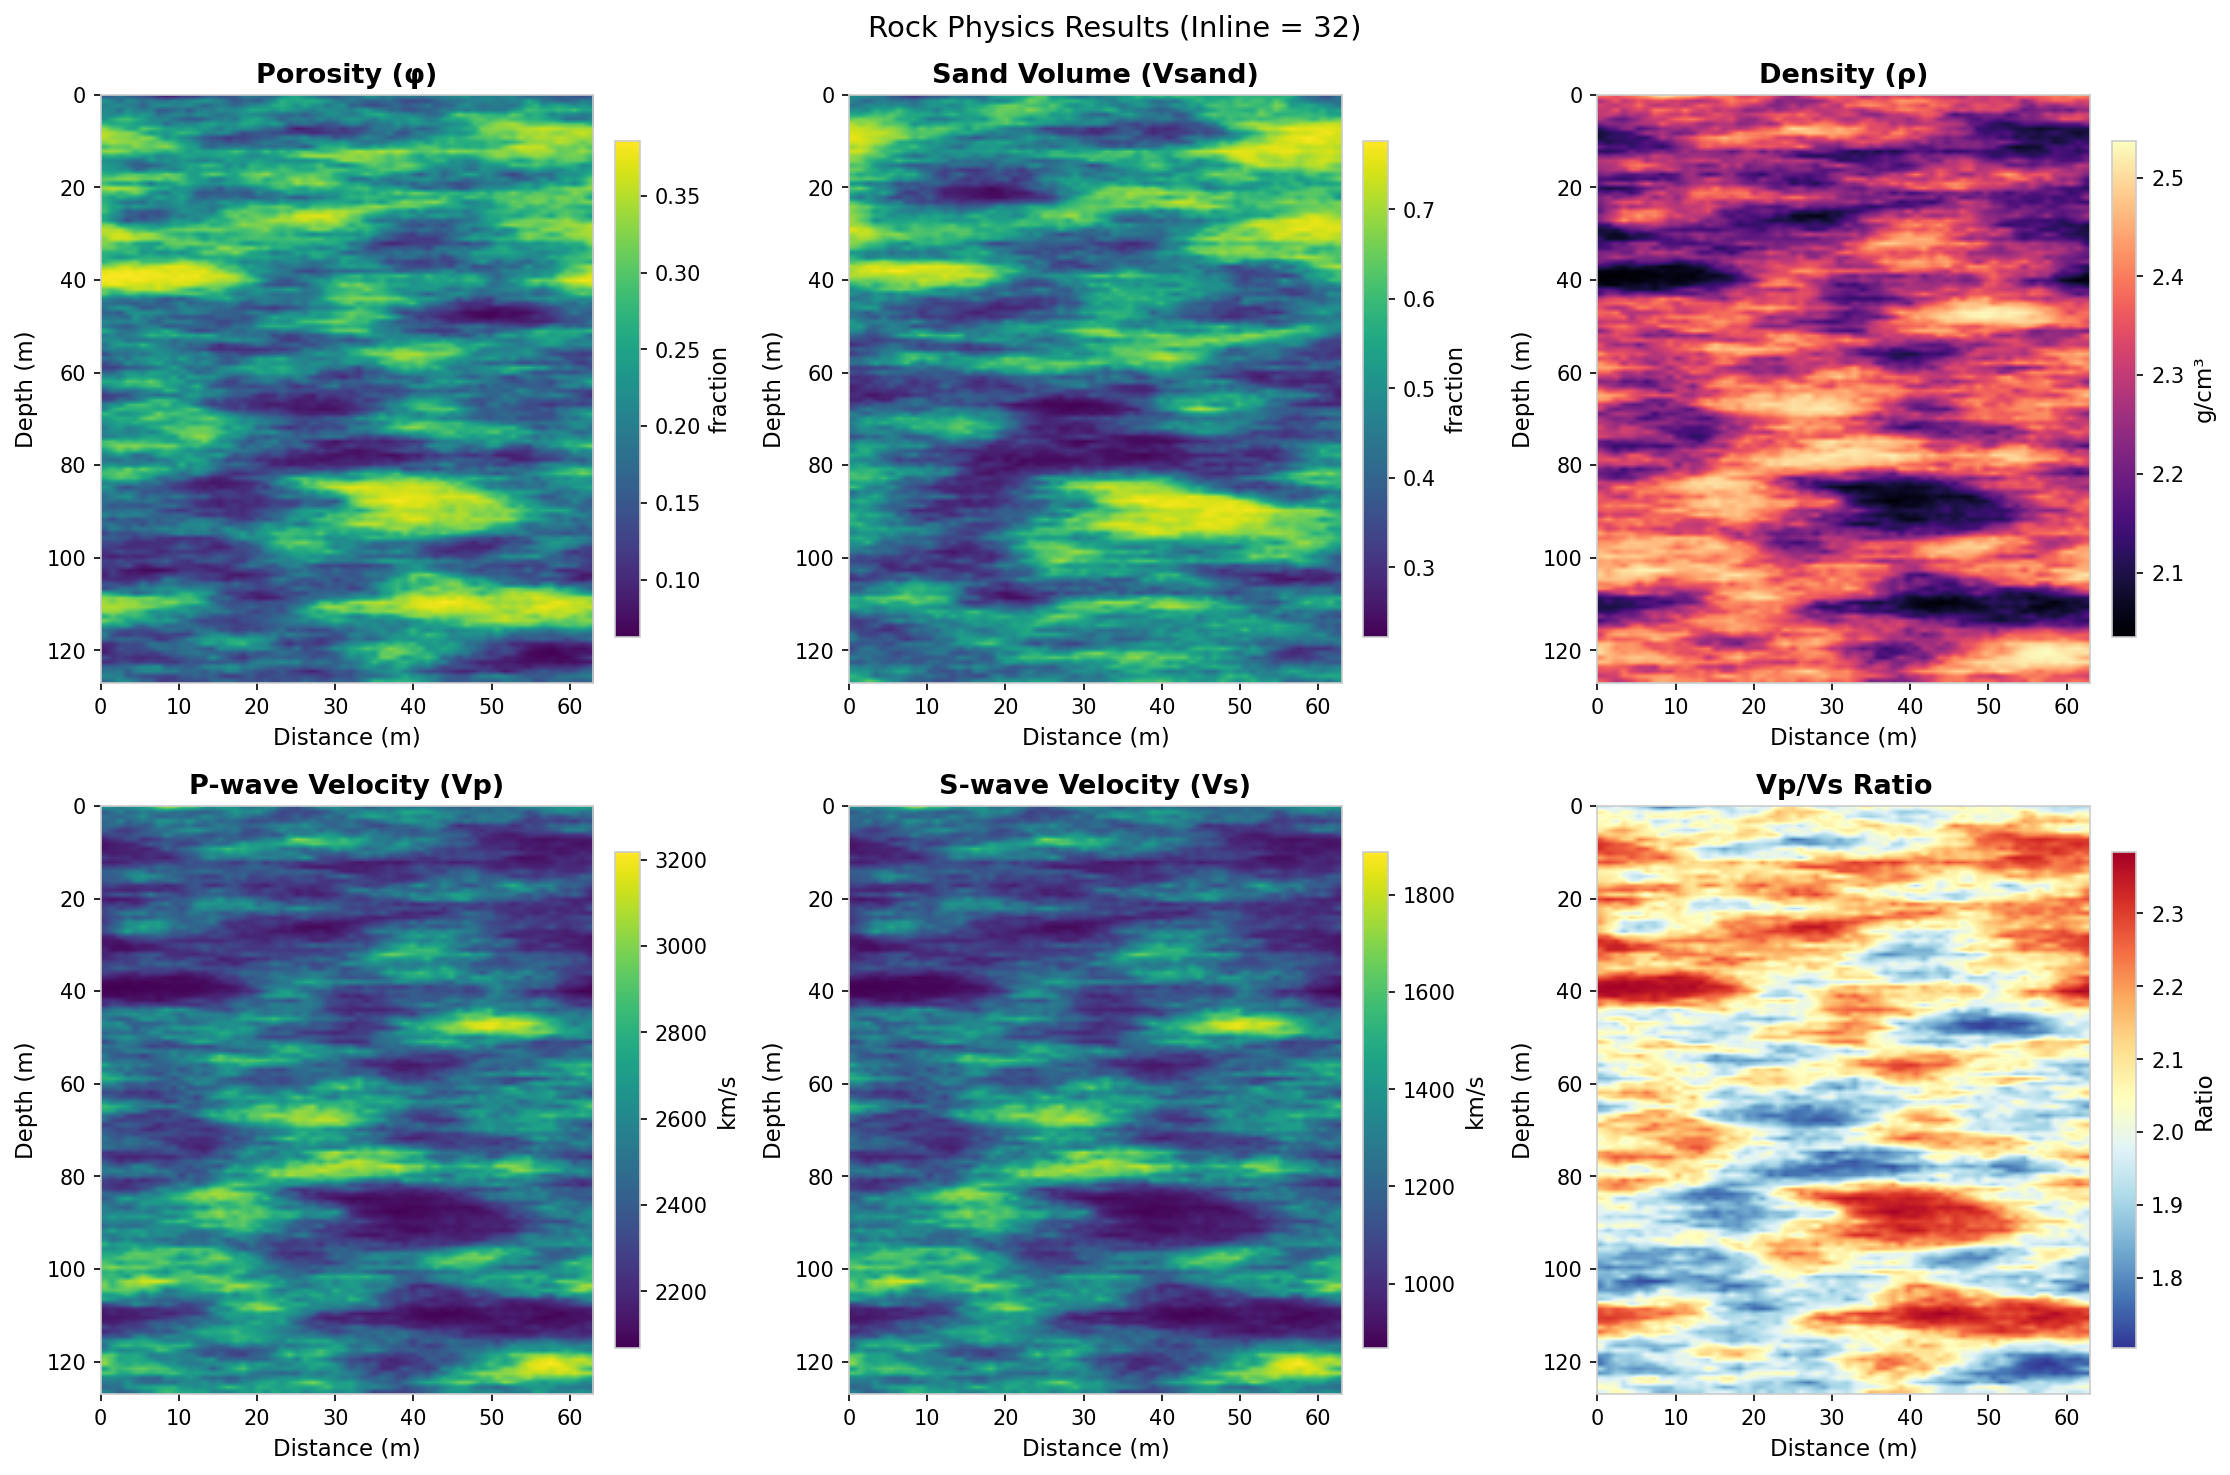

In [6]:
slice_idx = NX // 2

fig, axes = plt.subplots(2, 3, figsize=(15, 10))

plot_field(phi[slice_idx].T, ax=axes[0, 0], cmap='viridis', label='fraction')
axes[0, 0].set_title('Porosity (φ)')

plot_field(vsand[slice_idx].T, ax=axes[0, 1], cmap='viridis', label='fraction')
axes[0, 1].set_title('Sand Volume (Vsand)')

plot_field(rho[slice_idx].T, ax=axes[0, 2], cmap='magma', label='g/cm³')
axes[0, 2].set_title('Density (ρ)')

plot_field(vp[slice_idx].T, ax=axes[1, 0], cmap='viridis', label='km/s')
axes[1, 0].set_title('P-wave Velocity (Vp)')

plot_field(vs[slice_idx].T, ax=axes[1, 1], cmap='viridis', label='km/s')
axes[1, 1].set_title('S-wave Velocity (Vs)')

plot_field((vp / vs)[slice_idx].T, ax=axes[1, 2], cmap='RdYlBu_r', label='Ratio')
axes[1, 2].set_title('Vp/Vs Ratio')

fig.suptitle(f'Rock Physics Results (Inline = {slice_idx})', fontsize=14)
plt.tight_layout()
plt.savefig(os.path.join(FIGS_DIR, '05_rock_physics_fields.png'))
plt.show()

## Crossplot Analysis

Scatter plots of porosity vs. velocity reveal the expected inverse trend.
The spread around the trend line is caused by variations in sand volume and
other factors -- a valuable quality-control check for rock-physics
calibration.

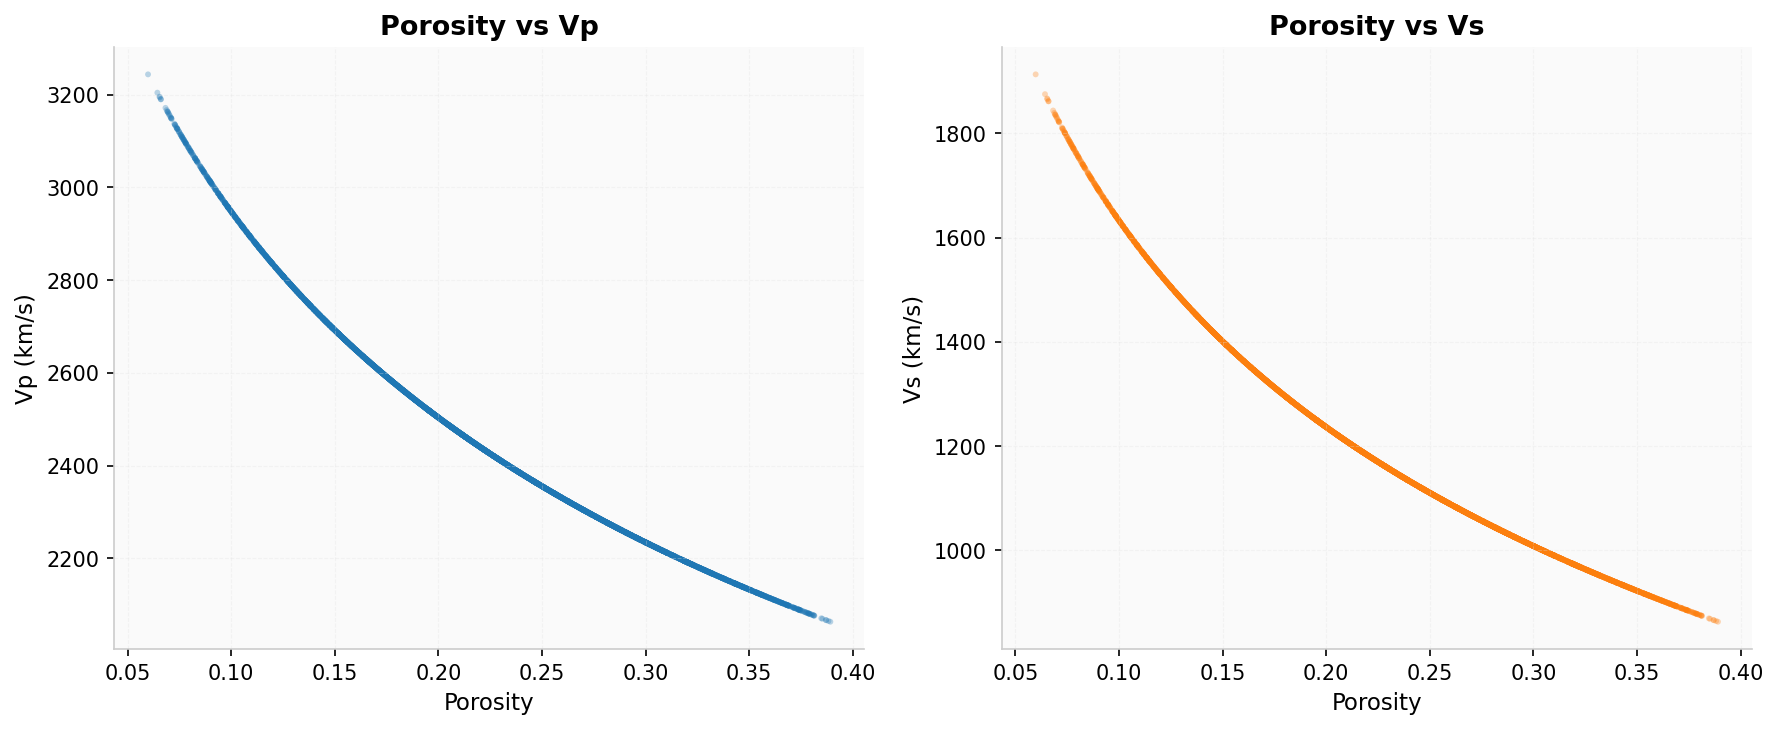

In [7]:
# Subsample for plotting
n_samples = 5000
indices = torch.randperm(phi.numel())[:n_samples]

phi_flat = phi.flatten()[indices].cpu().numpy()
vp_flat = vp.flatten()[indices].cpu().numpy()
vs_flat = vs.flatten()[indices].cpu().numpy()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(phi_flat, vp_flat, alpha=0.3, s=8, c='#1f77b4', edgecolors='none')
axes[0].set_xlabel('Porosity')
axes[0].set_ylabel('Vp (km/s)')
axes[0].set_title('Porosity vs Vp')
axes[0].grid(True, alpha=0.3, linestyle='--')
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

axes[1].scatter(phi_flat, vs_flat, alpha=0.3, s=8, c='#ff7f0e', edgecolors='none')
axes[1].set_xlabel('Porosity')
axes[1].set_ylabel('Vs (km/s)')
axes[1].set_title('Porosity vs Vs')
axes[1].grid(True, alpha=0.3, linestyle='--')
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig(os.path.join(FIGS_DIR, '05_crossplot.png'))
plt.show()